<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/Evaluaciones/PIA_ARIMA_conExogenos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##################################################
##                                              ##
##             PRODUCTO INTEGRADOR              ##
##    Pronósticos en la Cadena de Suministro    ##
##                                              ##
##  Método: ARIMA                               ##
##                                              ##
##  Saúl Roberto Morales Velázquez              ##
##  1856691                                     ##
##                                              ##
##################################################

#**Librerías**

In [12]:
# @title Librerías a importar

### Librerías de Google para uso en Colab.
from google.colab import files, userdata  # Permite utilizar los datos de usuario.

### Librerías para trabajar con los datos
from sklearn.metrics import mean_absolute_percentage_error as MAPE # Métricas de evaluación.
from statsmodels.tsa.stattools import adfuller, acf, pacf  #ADFuller permite diferenciar la estacionalidad; ACF y PACF permiten obtener las correlaciones.
import json # Permite trabajar con datos en formato JSON.
import numpy as np # Permite trabajar con opercaciones matemáticas avanzadas.
import pandas as pd # Permite trabajar con data frames.
import requests

### Librerías para generar gráficas
from prophet.plot import plot_plotly, plot_components_plotly  # Generador de gráficas de componentes de Meta Prophet.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Generador de gráficas de autocorrelación.
import matplotlib.pyplot as plt # Librería para generación de gráficas.
import plotly.express as px # Librería que permite la creación de gráficas interactivas.
import plotly.graph_objects as go # Librería que permite la creación de gráficas interactivas.

### Librería del modelo a utilizar
from statsmodels.tsa.arima.model import ARIMA # ARIMA, por statmodel.

### Otras librerías
import warnings # Libería que permite trabajar con advertencias.
warnings.filterwarnings('ignore') # Ignora las advertencias generadas.
from datetime import datetime

#**Funciones**

In [2]:
# @title Gráfica del conjunto de datos real

def real_plt(df: object, time_column_name: str, value_column_name: str, title: str, xaxis_title="Tiempo", yaxis_title="Eje y") :
  """
  Grafica la serie de tiempo con los datos reales.

  Args:
      df (object): DataFrame que contiene los datos a graficar.
      time_column_name (str): Nombre de la columna que contiene las fechas.
      value_column_name (str): Nombre de la columna que contiene los valores.
      title (str): Título de la gráfica.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = px.line(df, x=time_column_name, y=value_column_name, title=title)

  fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
      buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="YTD", step="year", stepmode="todate"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
      ])
    )
  )

  fig.update_layout(
    title = title,
    xaxis_title = xaxis_title,
    yaxis_title = yaxis_title
  )

  return fig.show()

In [3]:
# @title Gráfica comparativa del conjunto de datos real vs. el pronosticado

def real_vs_forecast_plt(real_df: object, real_time_column_name: str, real_value_column_name: str, forecast_df: object, title: str, forecast_value_column_name = 0, model_name_serie="Forecast", xaxis_title = "Tiempo", yaxis_title = "Eje y") :
  """
  Grafica la comparativa de las series de tiempo con los datos reales y pronosticados.

  Args:
      real_df (object): DataFrame que contiene los datos reales.
      real_time_column_name (str): Nombre de la columna que contiene las fechas de los datos reales.
      real_value_column_name (str): Nombre de la columna que contiene los valores reales.
      forecast_df (object): DataFrame que contiene los datos pronosticados.
      title (str): Título de la gráfica.
      forecast_time_column_name (str): Nombre de la columna que contiene las fechas de los datos pronosticados.
      forecast_value_column_name (str): Nombre de la columna que contiene los valores pronosticados.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = go.Figure()

  fig.add_trace(
      go.Scatter(
          x = forecast_df.index,
          y = forecast_df[forecast_value_column_name],
          name = model_name_serie,
          line = dict(color = "#8C000F", width = 3, dash = "dash")
      )
  )

  fig.add_trace(
      go.Scatter(
          x = real_df.index,
          y = real_df[real_value_column_name],
          name = "Real",
          line = dict(color = "olive", width = 3, dash = "dash")
      )
  )

  fig.update_layout(title = title, xaxis_title=xaxis_title, yaxis_title=yaxis_title)

  return fig.show()

#**Clases**

In [4]:
# @title Banxico restAPI

class banxico() :
  """
  Clase que permite trabajar con los datos abiertos obtenidos mediante la API de Banxico.

  Args:
      token (str): Token de Banxico.
  """
  def __init__(self, token: str) :
    self._token = token  # Token de la API de Banxico. El uso del guión bajo permite establecer que es una variable interna, por lo que no puede ser llamada fuera de la clase.
    self.serie_ID = "The serie ID hasn't been defined yet."  # Última serie de datos utilizada en el modelo.
    self.url = "The serie ID hasn't been defined yet." # URL con la última serie de datos utilizada en el modelo.
    self.response = "The serie ID hasn't been defined yet."  # Respuesta HTTP de la última petición.
    self.HTTP_status_code = 0 # Código de estatus HTTP de la última petición.
    self.HTTP_status = "The serie ID hasn't been defined yet." # Estatus HTTP legible por humanos de la última petición.
    self.json_data = "The serie ID hasn't been defined yet."  # Datos en formato JSON utilizados para la construcción del conjunto de datos.
    self.title = "The serie ID hasn't been defined yet."  # Título del conjunto de datos, obtenido de la petición HTTP original.
    self.df = pd.DataFrame()  # Conjunto de datos.

  def get_df(self, serie_ID: str) :
    """
    Obtiene los datos de la serie de Banxico en formato de conjunto de datos (data frame).

    Args:
        serie_ID (str): ID de la serie de datos.

    Returns:
        Object: Conjunto de datos.
    """

    import requests # Permite realizar peticiones HTML.
    HTTP_codes = {
      "200" : "OK",
      "400" : "Bad Request",
      "401" : "Unauthorized",
      "403" : "Forbidden",
      "404" : "Not Found",
      "500" : "Internal Server Error",
    } # Diccionario de estatus HTTP.

    self.url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{serie_ID}/datos?token={self._token}" # Construye la URL del API para la serie de datos y la almacena en la variable del objeto.

    self.response = requests.get(self.url)  # Petición HTML.
    self.HTTP_status_code = self.response.status_code # Almacena el código de la petición HTML.
    self.HTTP_status = HTTP_codes[str(self.HTTP_status_code)] # Almacena el significado del código HTML.

    self.json_data = self.response.json() # Petición en formato JSON.
    self.title = self.json_data["bmx"]["series"][0]["titulo"] # Extrae el título de la serie de datos del JSON y la almacena en una variable del objeto.
    self.df = pd.DataFrame(self.json_data["bmx"]["series"][0]["datos"]) # Extrae los datos del JSON y los almacena en un conjunto de datos.
    self.df["fecha"] = pd.to_datetime(self.df["fecha"], format="%d/%m/%Y")  # Convierte las fechas en formato STR en formato datetime.

    if self.HTTP_status_code == 200 : # Revisa si la petición es correcta.
      return self.df  # Si es correcta, retorna el conjunto de datos.
    else :  # De lo contrario…
      print(f"Ha ocurrido un error: ({self.HTTP_status_code}) {self.HTTP_status}")  # Imprime el código de error
      return None # Y no retorna nada

#**Conjunto de datos**

In [5]:
# @title Parámetros de obtención de datos

## Solo muestra Banxico, ya que no tengo ninguna otra fuente de datos.
Fuente = "Banxico" # @param ["Banxico"]

## Series de tiempo de Banxico que he precargado.
Datos = "Tipo de cambio MXN/USD" # @param ["Tipo de cambio MXN/USD","Monto de ventas CETES 28","Tasa de descuento CETES 28"]

series_dict = {
    "Tipo de cambio MXN/USD" : "SF43718",
    "Monto de ventas CETES 28" : "SF116765",
    "Tasa de descuento CETES 28" : "SF116766"
} # Diccionario con las series de tiempo y las descripciones mostradas anteriormente.

banxico_serieID = series_dict[Datos]  # Busca el id de la serie de tiempo en el diccionario.

data = banxico(userdata.get('Banxico_Token')) # Usa la clase banxico para interactuar con la API.
df = data.get_df(banxico_serieID) # Extrae la serie de tiempo elegida.
df.head() # Muestra el encabezado de la serie de tiempo.

,fecha,dato
0,1991-11-12,3.0735
1,1991-11-13,3.0712
2,1991-11-14,3.0718
3,1991-11-15,3.0684
4,1991-11-18,3.0673


In [6]:
# @title Gráfica del conjunto de datos real
real_plt(df, "fecha", "dato", data.title, yaxis_title="Tipo de cambio")

In [24]:
df4model = df.copy()  # Copia el conjunto de datos original en uno nuevo para alimentar el modelo.
df4model["dato"] = pd.to_numeric(df["dato"], errors="coerce") # Convierte los datos string de Banxico en datos numéricos int64.
df4model.set_index("fecha", inplace=True) # Convierte el índice INT en un índice datetime.

df4model # Muestra las primeras filas del conjunto de datos.

,dato
fecha,
1991-11-12,3.0735
1991-11-13,3.0712
1991-11-14,3.0718
1991-11-15,3.0684
1991-11-18,3.0673
...,...
2025-03-28,20.4003
2025-03-31,20.4380
2025-04-01,20.3587


In [25]:
fechas_completas = pd.date_range(start=df4model.index.min(), end=df4model.index.max(), freq='D')  # Rellena las fechas faltantes en el índice.
fechas_faltantes = fechas_completas.difference(df4model.index)  # Busca las fechas faltantes y las almacena en una lista.
print(f"Fechas faltantes: {fechas_faltantes}")  # Imprime la lista de las fechas faltantes.
df4model = df4model.reindex(fechas_completas)  # Agrega las fechas faltantes con NaN.
df4model['dato'].fillna(method='ffill', inplace=True)  # Rellenar con el último valor válido.

Fechas faltantes: DatetimeIndex(['1991-11-16', '1991-11-17', '1991-11-20', '1991-11-23',
               '1991-11-24', '1991-11-30', '1991-12-01', '1991-12-07',
               '1991-12-08', '1991-12-12',
               ...
               '2025-03-02', '2025-03-08', '2025-03-09', '2025-03-15',
               '2025-03-16', '2025-03-17', '2025-03-22', '2025-03-23',
               '2025-03-29', '2025-03-30'],
              dtype='datetime64[ns]', length=3804, freq=None)


# **Serie de tiempo exógena**

In [26]:
interest = data.get_df("SF61745")
interest

,fecha,dato
0,2008-01-21,7.5000
1,2008-01-22,7.5000
2,2008-01-23,7.5000
3,2008-01-24,7.5000
4,2008-01-25,7.5000
...,...,...
6184,2025-03-31,9.0000
6185,2025-04-01,9.0000
6186,2025-04-02,9.0000
6187,2025-04-03,9.0000


In [50]:
df4exog = interest.copy()  # Copia el conjunto de datos original en uno nuevo para alimentar el modelo.
df4exog["dato"] = pd.to_numeric(interest["dato"], errors="coerce") # Convierte los datos string de Banxico en datos numéricos int64.
df4exog.set_index("fecha", inplace=True) # Convierte el índice INT en un índice datetime.

fechas_completas = pd.date_range(start=df4exog.index.min(), end=df4exog.index.max(), freq='D')  # Rellena las fechas faltantes en el índice.
fechas_faltantes = fechas_completas.difference(df4exog.index)  # Busca las fechas faltantes y las almacena en una lista.
print(f"Fechas faltantes: {fechas_faltantes}")  # Imprime la lista de las fechas faltantes.
df4exog = df4exog.reindex(fechas_completas)  # Agrega las fechas faltantes con NaN.
df4exog['dato'].fillna(method='ffill', inplace=True)  # Rellenar con el último valor válido.

Fechas faltantes: DatetimeIndex(['2008-01-26', '2008-01-27', '2008-02-02', '2008-02-03',
               '2008-02-04', '2008-02-09', '2008-02-10', '2008-02-16',
               '2008-02-17', '2008-02-23', '2008-02-24', '2008-03-01',
               '2008-03-02', '2008-03-08', '2008-03-09', '2008-03-15',
               '2008-03-16', '2008-03-17', '2008-03-20', '2008-03-21',
               '2008-03-22', '2008-03-23', '2008-03-29', '2008-03-30',
               '2008-04-05', '2008-04-06', '2008-04-12', '2008-04-13',
               '2008-04-19', '2008-04-20', '2008-04-26', '2008-04-27',
               '2008-05-01', '2008-05-03', '2008-05-04', '2008-05-10',
               '2008-05-11', '2008-05-17', '2008-05-18', '2008-05-24',
               '2008-05-25', '2008-05-31', '2008-06-01', '2008-06-07',
               '2008-06-08', '2008-06-14', '2008-06-15', '2008-06-21',
               '2008-06-22', '2008-06-28', '2008-06-29', '2008-07-05',
               '2008-07-06', '2008-07-12', '2008-07-13', '2

In [51]:
df4exog = df4exog[df4exog.index <= datetime(2025,4,3)]
df4exog

,dato
2008-01-21,7.5
2008-01-22,7.5
2008-01-23,7.5
2008-01-24,7.5
2008-01-25,7.5
...,...
2025-03-30,9.0
2025-03-31,9.0
2025-04-01,9.0
2025-04-02,9.0


In [52]:
real_plt(interest, "fecha", "dato", data.title, yaxis_title="Inflación mensual")

In [53]:
df4model = df4model[df4model.index >= datetime(2008,1,21)]
df4model

,dato
2008-01-21,10.9813
2008-01-22,10.9232
2008-01-23,10.9522
2008-01-24,10.8934
2008-01-25,10.8698
...,...
2025-03-30,20.4003
2025-03-31,20.4380
2025-04-01,20.3587
2025-04-02,20.4568


#**ARIMA**

<Figure size 1200x600 with 0 Axes>

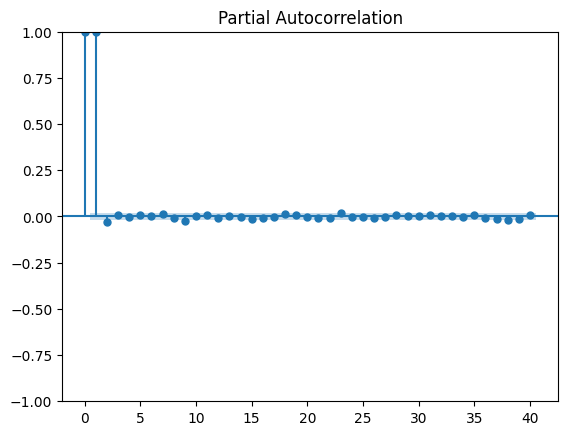

<Figure size 1200x600 with 0 Axes>

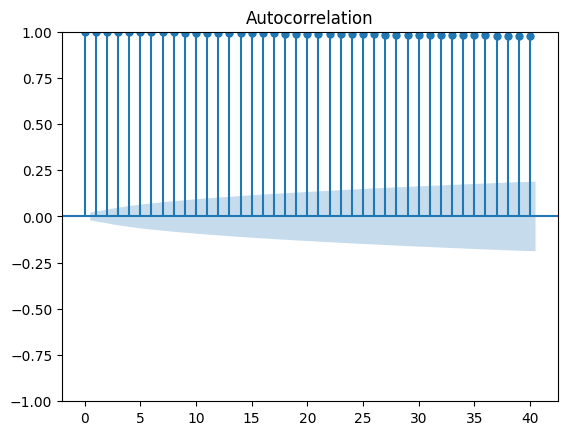

{'p-value (ADF)': np.float64(0.6132573558116968), 'ACF': array([1.        , 0.99946049, 0.99888895, 0.99832395, 0.99775851,
       0.99719963, 0.9966454 , 0.99610389, 0.99555383, 0.99497955,
       0.99440616, 0.99384287, 0.99327186, 0.992704  , 0.99213689,
       0.99155703, 0.99096977, 0.99037853, 0.98980242, 0.98923459,
       0.98866343, 0.98808444, 0.98749641, 0.98693007, 0.98636259,
       0.98579082, 0.98521215, 0.98463313, 0.98406146, 0.98349185,
       0.98292583, 0.98237251, 0.98182165, 0.98127211, 0.98072243,
       0.98017975, 0.97962855, 0.97906182, 0.9784759 , 0.97787846,
       0.97728753]), 'PACF': array([ 1.00000000e+00,  9.99579590e-01, -3.84446361e-02,  8.89496254e-03,
       -1.50146538e-03,  7.59892961e-03,  4.59289722e-03,  1.45583136e-02,
       -1.16005916e-02, -2.81053614e-02,  2.75093823e-03,  1.13649310e-02,
       -1.03989655e-02,  4.04048975e-03, -4.99262096e-04, -1.60802520e-02,
       -7.40674168e-03, -3.65818013e-03,  1.73604969e-02,  7.54260914e-03,
   

In [54]:
# @title Determinación de valores *p,d,q*

# La gráfica de correlación parcial permite determinar el mejor valor para *p*.
plt.figure(figsize=(12,6))  # Establece el tamaño de la figura.
plot_pacf(df['dato'], lags=40)  # Selecciona la columna de los datos a graficar bajo el método PACF.
PACF_value = pacf(df['dato'], nlags=40) # Obtiene el PACF.
plt.show()  # Muestra la gráfica.

# La prueba de Dickey-Fuller Aumentada (ADF) permite determinar si un conjunto de datos posee estacionalidad (<0.05) o no (>0.05). Útil para determina *d*.
ADF = adfuller(df['dato'])

# La gráfica de autocorrelación (AR) permite determinar el mejor valor para *q*.
plt.figure(figsize=(12,6))  # Establece el tamaño de la figura.
plot_acf(df['dato'], lags=40) # Selecciona la columna de los datos a graficar bajo el método ACF.
ACF_value = acf(df['dato'], nlags=40) # Obtiene el ACF.
plt.show()  # Muestra la gráfica.

other_dict = {
    "p-value (ADF)" : ADF[1],
    "ACF" : ACF_value,
    "PACF" : PACF_value
} # Diccionario de los valores ADF (p), ACF (d) y PACF (q).

print(other_dict) # Muestra del diccionario
if ADF[1] < 0.05 :  # Determina si la serie de tiempo tiene estacionalidad o no.
  print("\nLa serie es estacionaria.")
else :
  print("\nLa serie no es estacionaria.")

In [55]:
# @title Parámetros del modelo
# @markdown Parámetros generales
Días_a_pronosticar = 90 # @param {"type":"slider","min":0,"max":90,"step":1}
Tendencia = "Linear" # @param ["Constante","Linear"]
Frecuencia = "Diaria" # @param ["Diaria","Semanal","Mensual","Trimestral","Anual"]

# @markdown Parámetros ARIMA
Valor_p = 2 # @param {"type":"slider","min":0,"max":10,"step":1}
Valor_d = 1 # @param {"type":"slider","min":0,"max":10,"step":1}
Valor_q = 0 # @param {"type":"slider","min":0,"max":10,"step":1}

Tendencia_dict = {
    "Constante" : "c",
    "Linear" : "t"
} # Diccionario de frecuencias de statsmodels

Frecuencias_dict = {
    "Diaria" : "D",
    "Semanal" : "W",
    "Mensual" : "M",
    "Trimestral" : "Q",
    "Anual" : "A"
} # Diccionario de frecuencias de statsmodels

### Traducciones al inglés
days2forecast = Días_a_pronosticar
frequency = Frecuencias_dict[Frecuencia]
trend_model = Tendencia_dict[Tendencia]

In [67]:
future_exog = []
for i in range(0,90) :
  future_exog.append(0)

future_exog

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [68]:
# @title Entrenamiento del modelo

model = ARIMA(endog=df4model["dato"], exog=df4exog, order=(Valor_p,Valor_d,Valor_q), trend=trend_model, freq=frequency).fit() # Modelo con los parámetros establecidos p,d,q.

forecast = model.predict(start=0, end=len(df4model)+days2forecast-1, exog=future_exog)  # Predice el conjunto de datos original + la cantidad de días asignada en los parámetros.
forecast = pd.DataFrame(forecast) # Convierte el forecast en un conjunto de datos, ya que originalmente es una lista.
forecast.head() # Muestra las primeras filas del conjunto de datos.

,predicted_mean
2008-01-21,-0.427768
2008-01-22,10.982737
2008-01-23,10.922705
2008-01-24,10.953280
2008-01-25,10.893494


In [69]:
# @title Gráfica del conjunto de datos real vs. el pronosticado

real_vs_forecast_plt(real_df = df4model, real_time_column_name = "fecha", real_value_column_name = "dato", forecast_df = forecast, title="Tipo de cambio real vs ARIMA", model_name_serie="ARIMA", yaxis_title = "Tipo de cambio", forecast_value_column_name = "predicted_mean")  # Crea la gráfica comparativa de las ventas reales vs el pronóstico.

#**MAPE**

In [70]:
mape_value = MAPE(df4model["dato"], forecast.iloc[:-days2forecast]["predicted_mean"]) * 100 # Función mean_absolute_percentage_error (MAPE) de sklearn
mape_value  # Muestra el MAPE.

0.3934169458640762

#**Descarga de datos**

In [ ]:
forecast.to_csv("forecast_ARIMA.csv") # Exporta el conjunto de datos de la predicción aun archivo csv.
files.download("forecast_ARIMA.csv") # Descarga el archivo localmente.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>